## Кейс онлайн-магазина

Продуктовый менеджер магазина хотел бы по данным за всю историю посмотреть, сколько у нас было пользователей по разным типам устройств в неделю и оценить наглядно, зависит ли количество добавлений в корзину от количества уникальных посетителей.

In [3]:
import pandas as pd
from datetime import timedelta
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline  

In [2]:
sns.set_style('darkgrid')

In [4]:
df = pd.read_csv('data/online_store.csv')
df['date_x'] = pd.to_datetime(df['date']) 
df['week_date'] = df['date_x'] - df['date_x'].dt.weekday.apply(timedelta)

/var/folders/4g/ybnkwh793rb53vbrq1hfsp5c0000gn/T/ipykernel_82414/4161491890.py:1: DtypeWarning: Columns (0: fullVisitorId) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/online_store.csv')


In [5]:
# считаем уникальных посетителей по категориям устройств в неделю
df_weekly_uniqs = df.groupby(['week_date', 'deviceCategory'], as_index=False)[['fullVisitorId']].nunique()
df_weekly_uniqs = df_weekly_uniqs.rename(columns={'fullVisitorId': 'uniq_users'})

In [6]:
# выбираем только мобильных пользователей
df_wu_mobile = df_weekly_uniqs[df_weekly_uniqs['deviceCategory'] == 'mobile']

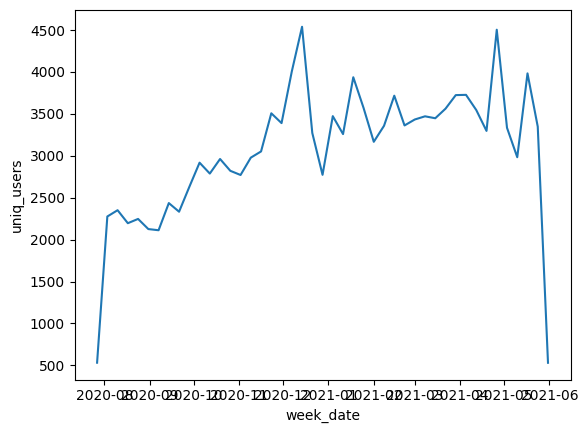

In [ ]:
sns.lineplot(data=df_wu_mobile, x='week_date', y='uniq_users')
plt.show()

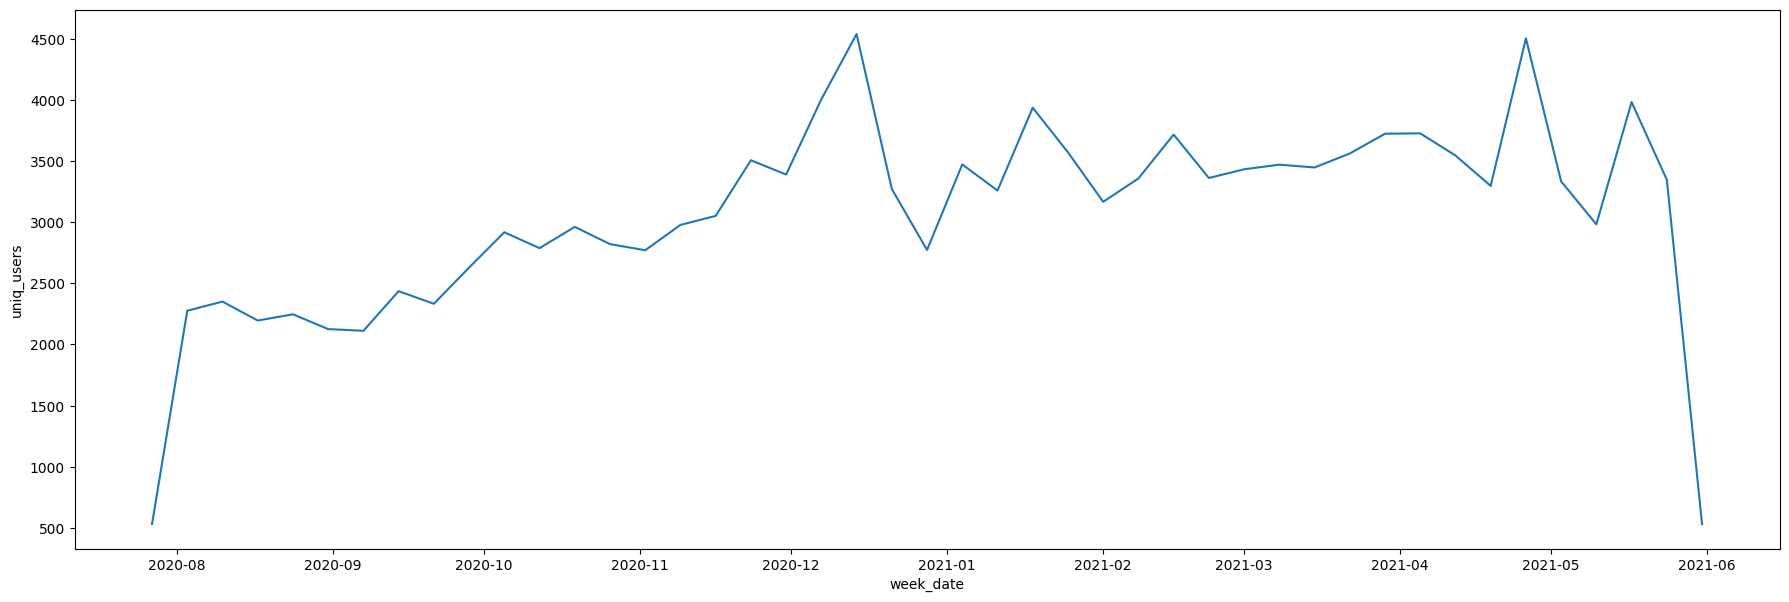

In [ ]:
plt.figure(figsize=(22,7))
sns.lineplot(data=df_wu_mobile, x='week_date', y='uniq_users')
plt.show()

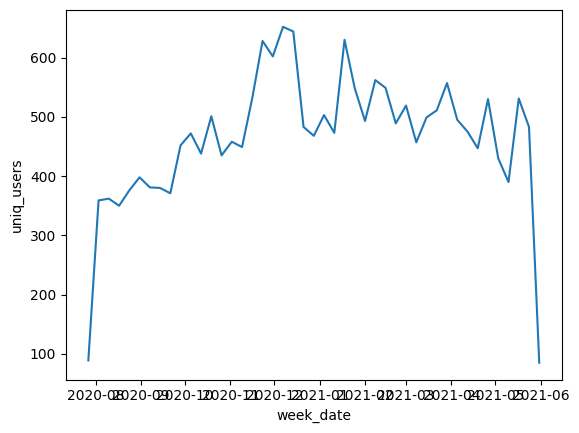

In [9]:
# рисуем планшеты
df_wu_tablet = df_weekly_uniqs[df_weekly_uniqs['deviceCategory'] == 'tablet']
sns.lineplot(data=df_wu_tablet, x='week_date', y='uniq_users')
plt.show()

In [10]:
# устанавливаем размер для графиков по-умолчанию
plt.rcParams['figure.figsize'] = [22, 7]

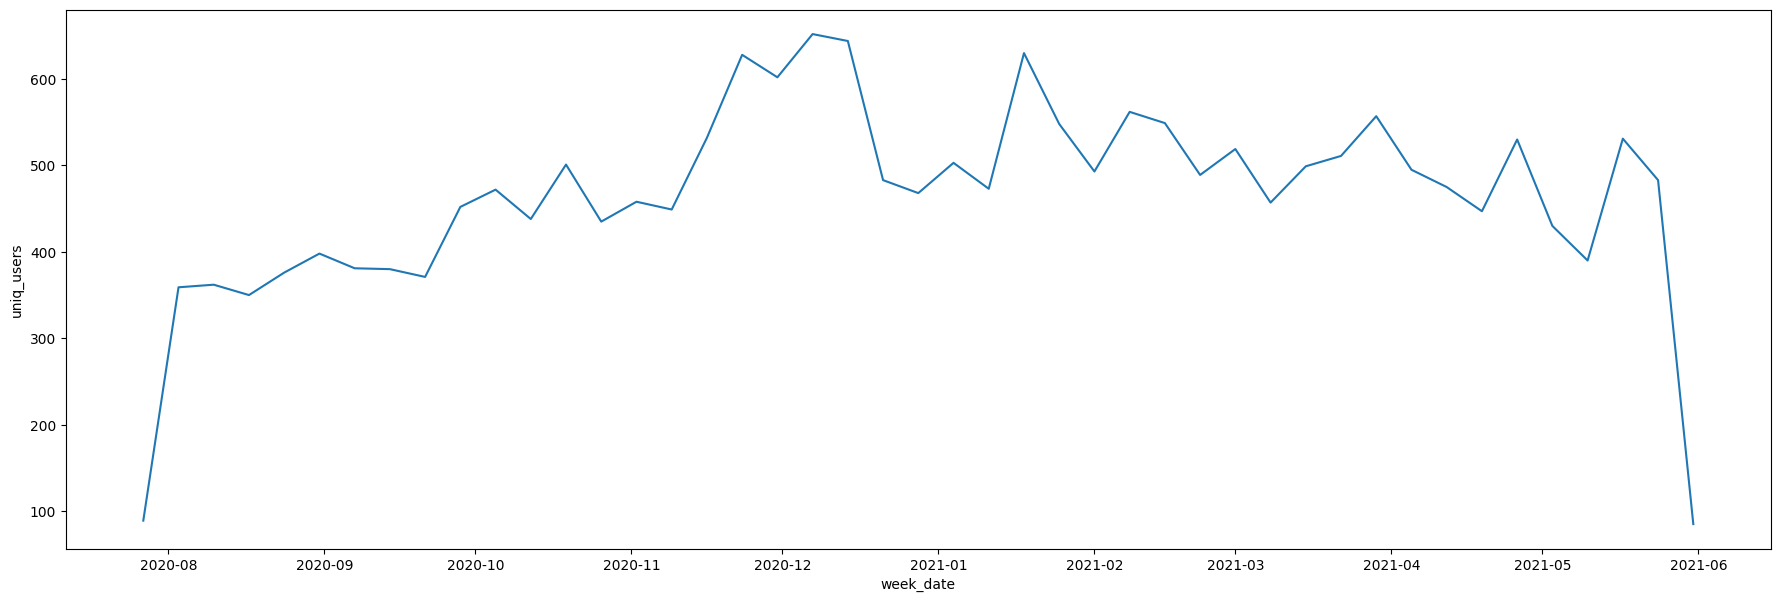

In [11]:
sns.lineplot(data=df_wu_tablet, x='week_date', y='uniq_users')
plt.show()

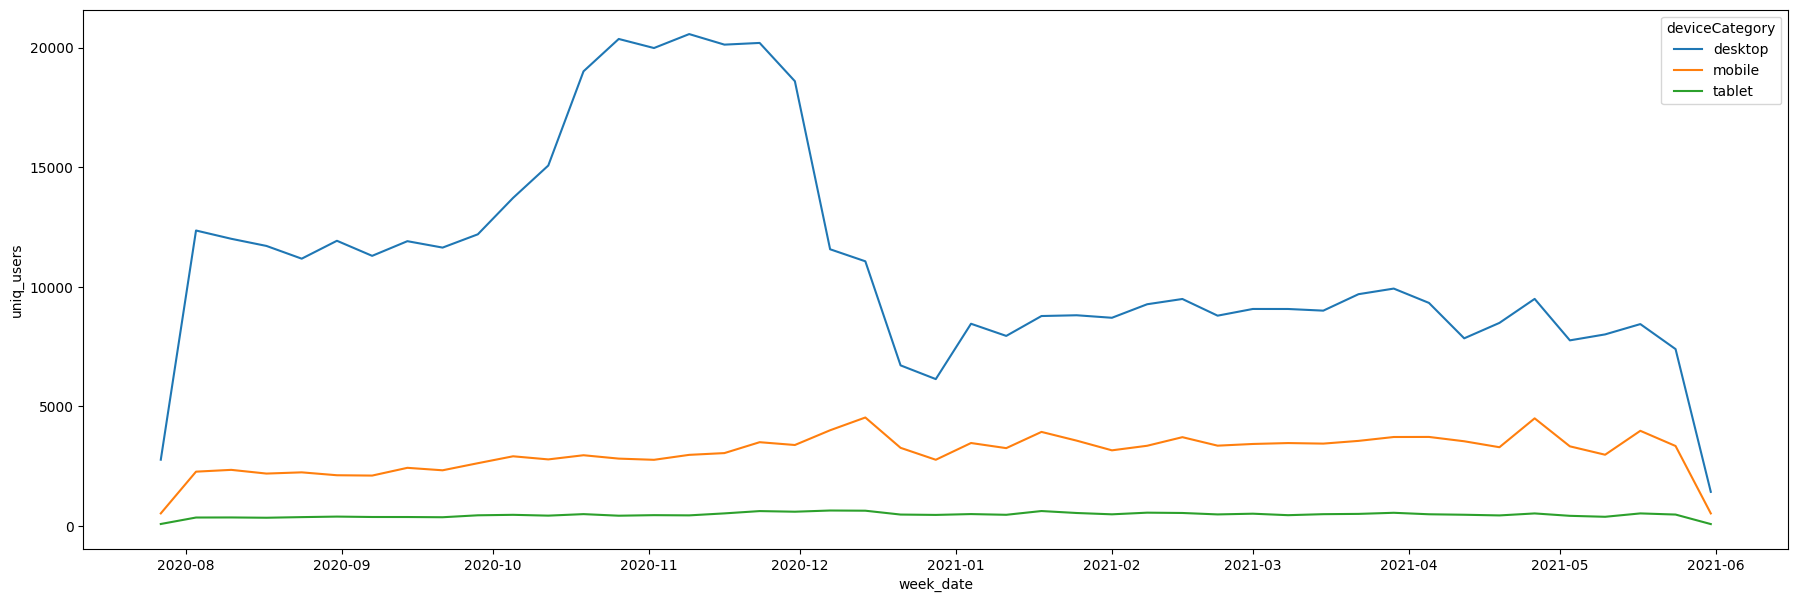

In [ ]:
sns.lineplot(data=df_weekly_uniqs, x='week_date', y='uniq_users', hue='deviceCategory')
plt.show()

### Дополняем данные добавлениями в корзину
Чтобы сравнить количество посетителей и количество положенных товаров в корзину добавляем новый показатель

In [17]:
df_atc = df.groupby(['week_date', 'deviceCategory'], as_index=False)[['addedToCart']].sum()
df_report = pd.merge(df_weekly_uniqs, df_atc, on=('week_date', 'deviceCategory'))
df_report_sum = df_report.groupby('week_date', as_index=False).sum()

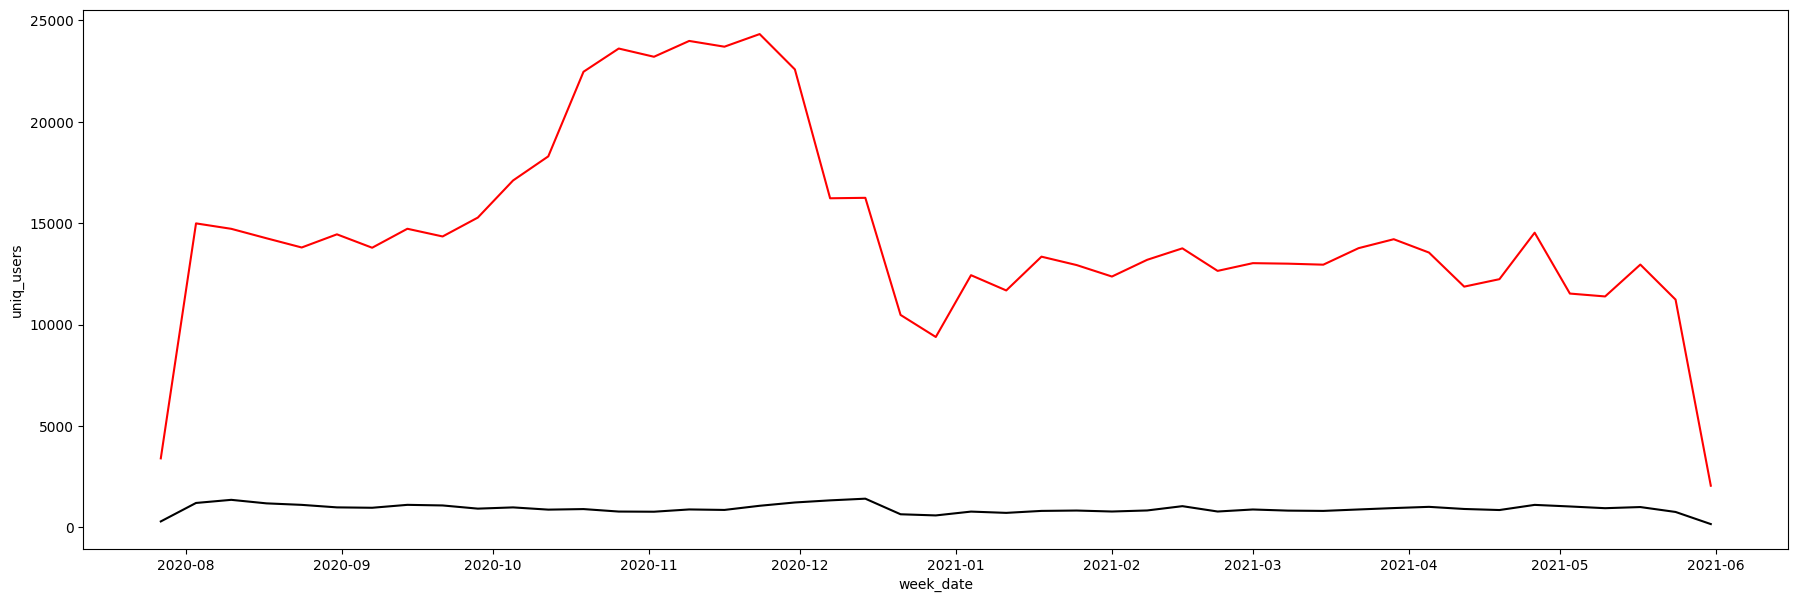

In [18]:
# рисуем два разных показателя на одном графике, красным и чёрным цветом
sns.lineplot(data=df_report_sum, x='week_date', y='uniq_users', color='r')
sns.lineplot(data=df_report_sum, x='week_date', y='addedToCart', color='black')
plt.show()

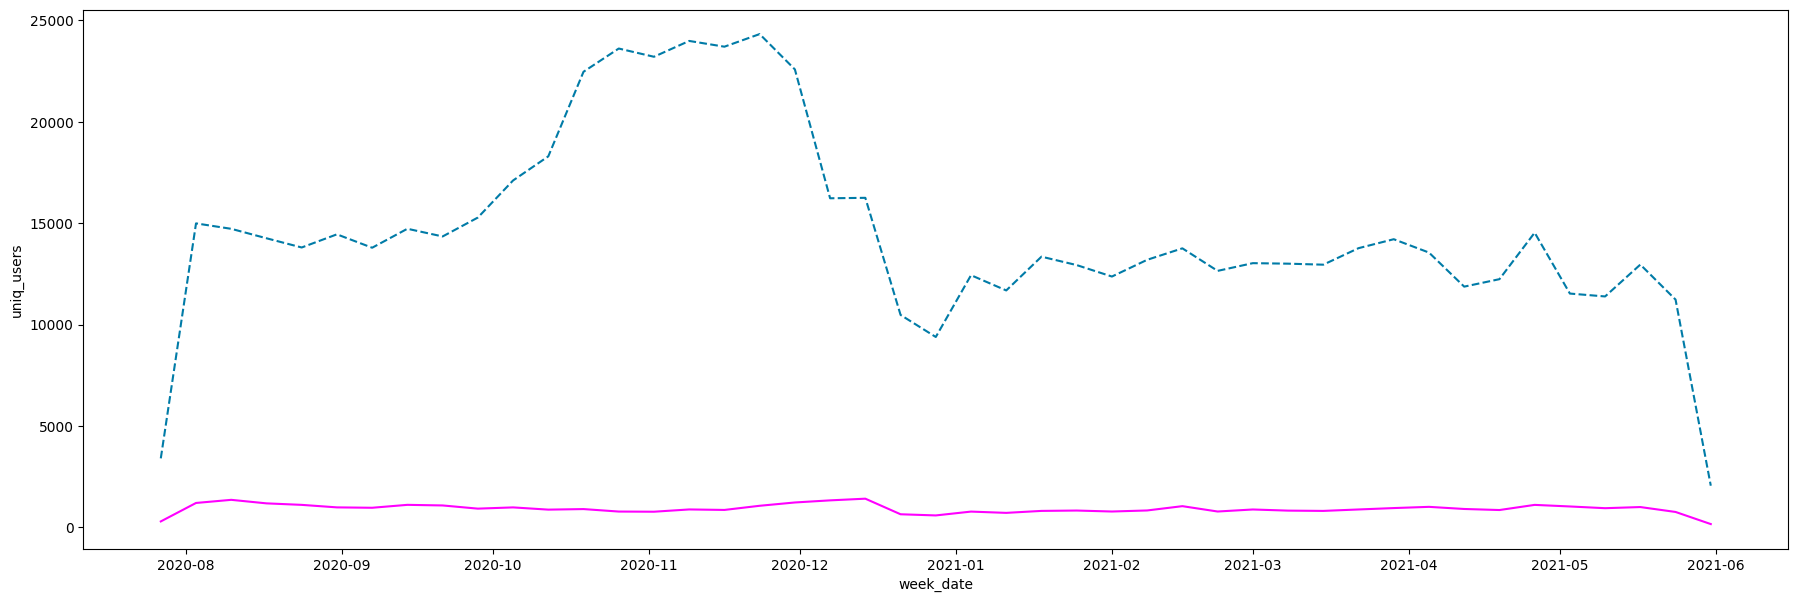

In [19]:
sns.lineplot(data=df_report_sum, x='week_date', y='uniq_users', color='#007ba7', linestyle='--')
sns.lineplot(data=df_report_sum, x='week_date', y='addedToCart', color='#ff00ff')

plt.show()

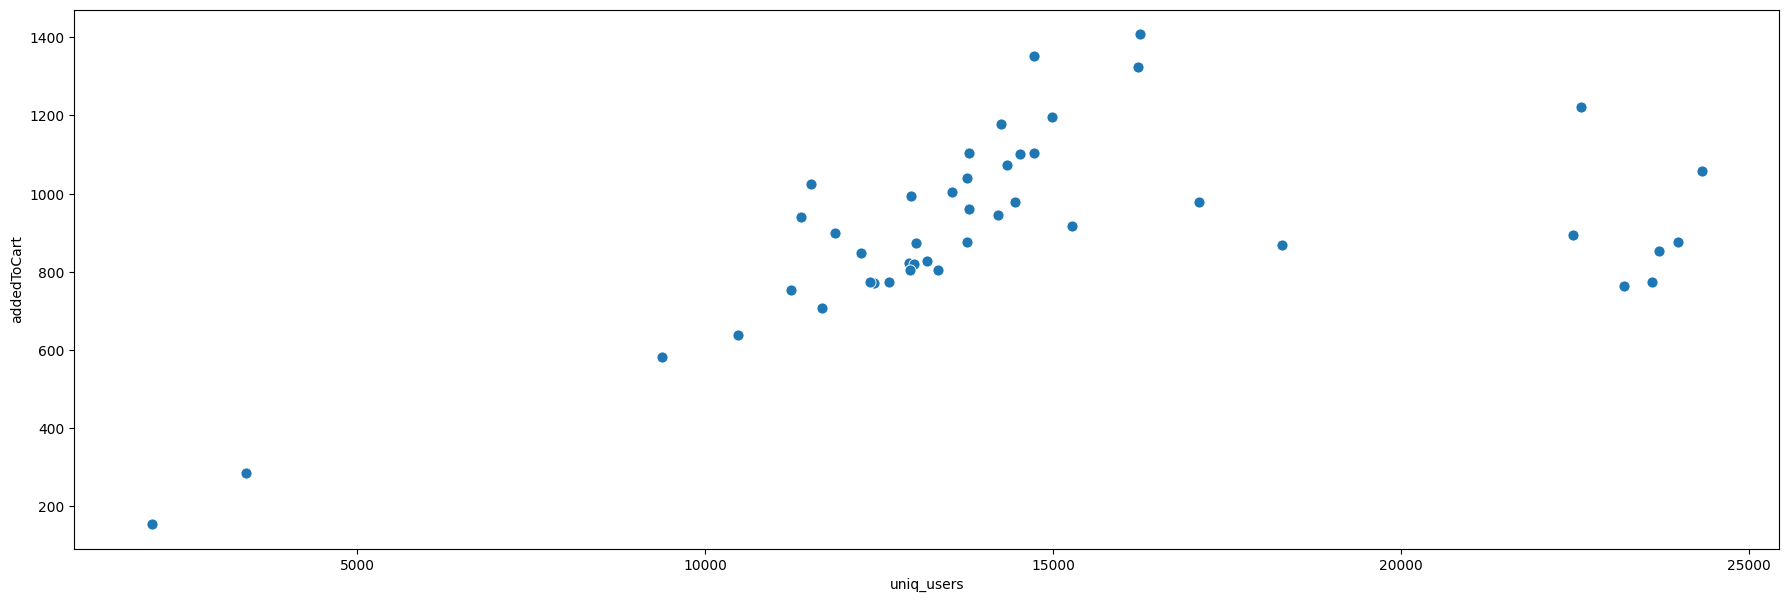

In [20]:
# по ощущениям от прошлого графика выглядит так, что кол-во добавлений в корзину не сильно меняется от количества пользователей
# можно наглядно посмотреть на зависимость двух показателей с помощью scatterplot
sns.scatterplot(data=df_report_sum, x='uniq_users', y='addedToCart')
plt.show()

**Вывод**: видим, что до некоторого порога в районе 15000-17000 пользователей, количество добавлений в корзину растет линейно. 
После этого порога картина хаотичная, зависимости показателей не наблюдается

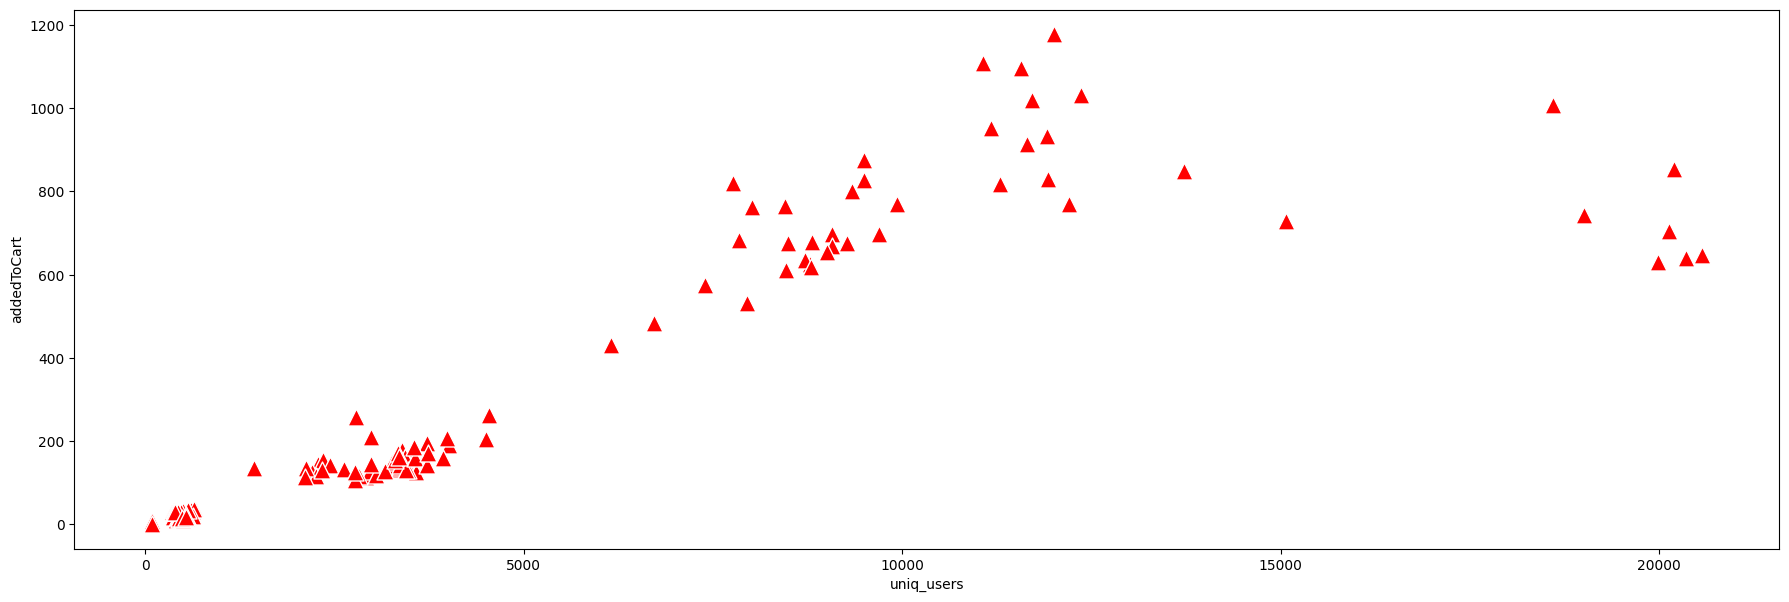

In [ ]:
sns.scatterplot(data=df_report, x='uniq_users', y='addedToCart', marker="^", s=150, c=['r'])
plt.show()

In [22]:
plt.rcParams['lines.markersize'] = 8

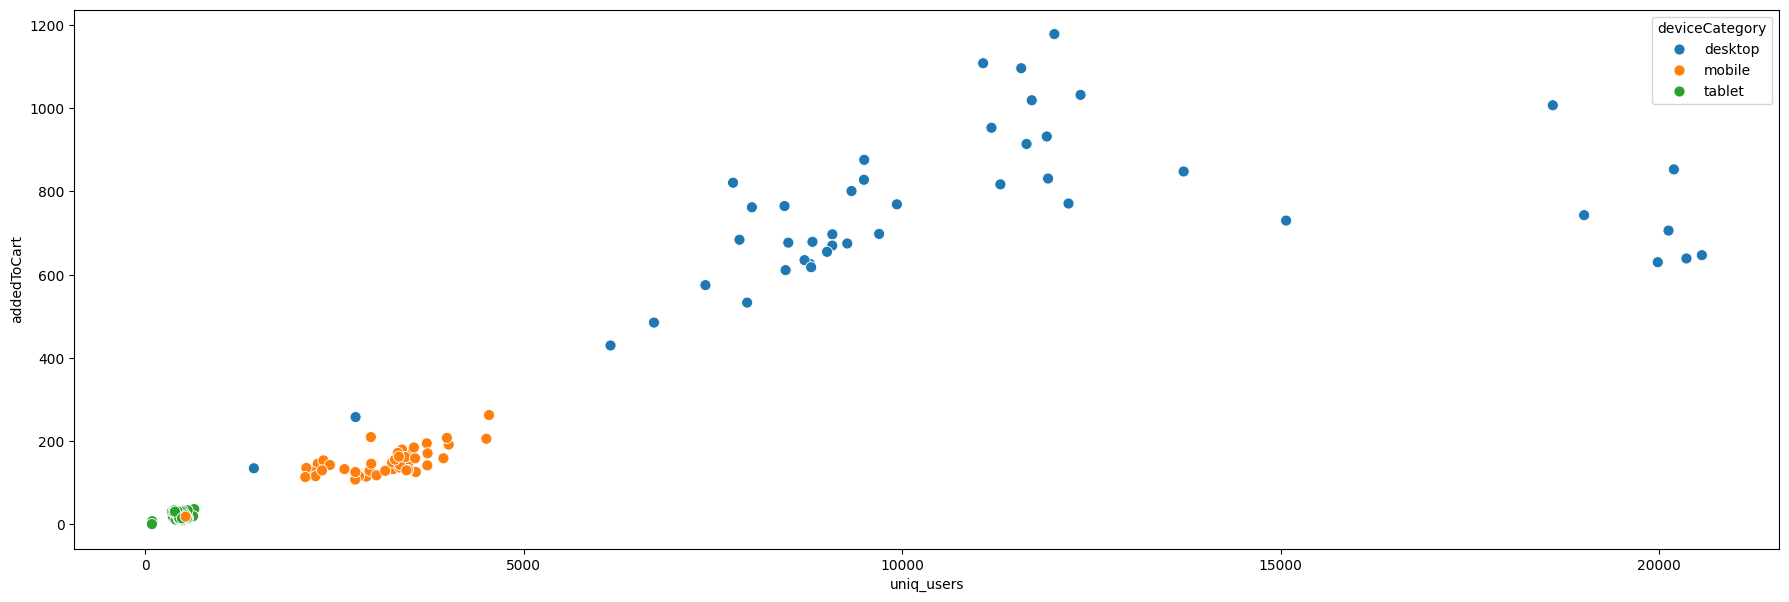

In [ ]:
# на прошлом графике видны 3 кучки точек. скорее всего это разные типы устройств
# разделим цветами типы устройств
sns.scatterplot(data=df_report, x='uniq_users', y='addedToCart', hue='deviceCategory')
plt.show()

**Вывод**: видим, что до некоторого порога в районе 13000-15000 пользователей, количество добавлений в корзину растет линейно для данных по декстопам. После этого порога картина хаотичная, зависимости показателей не наблюдается.  
Для данных по мобильной версии видим линейную зависимость на всём промежутке.   
Для данных по планшетной версии выводы делать сложно, так как масштаб графика слишком большой.  

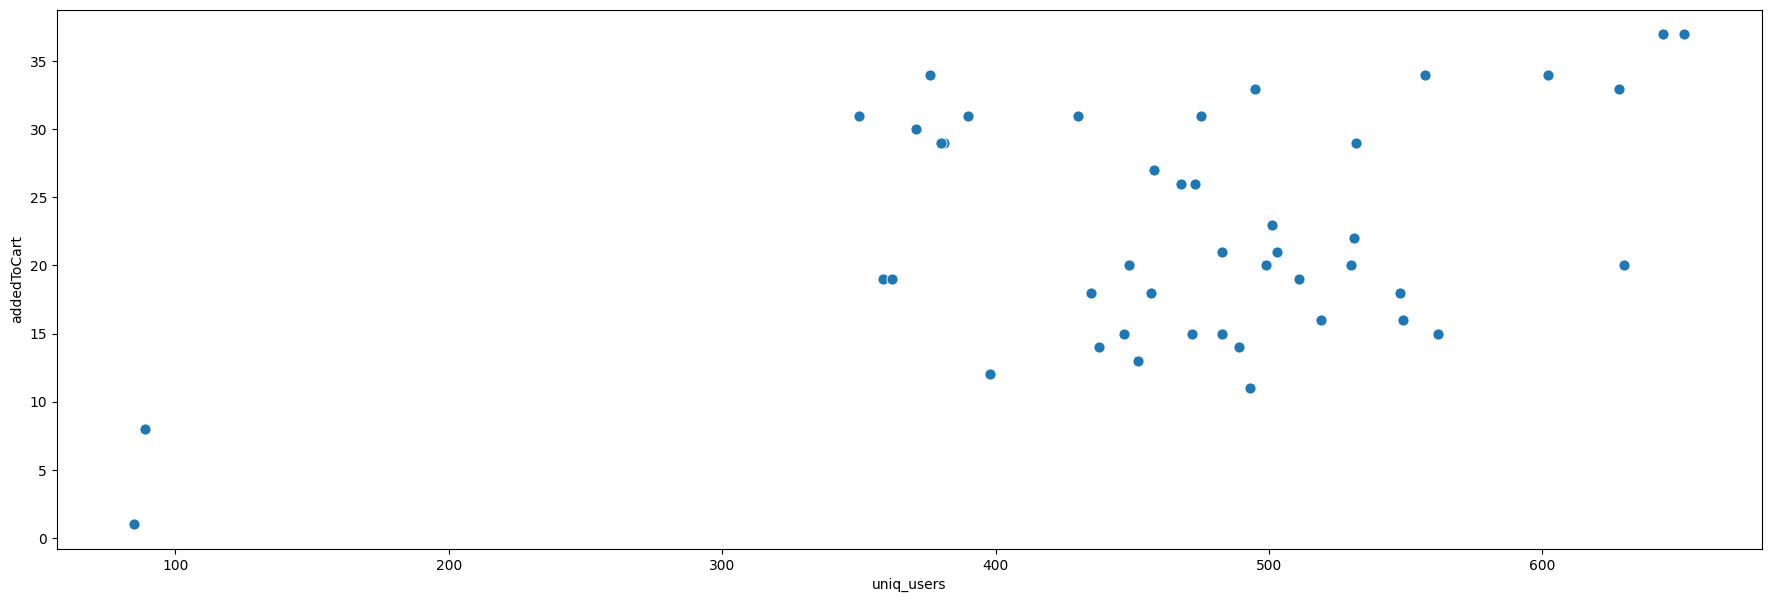

In [24]:
df_report_tablet = df_report[df_report['deviceCategory'] == 'tablet']
sns.scatterplot(data=df_report_tablet, x='uniq_users', y='addedToCart')
plt.show()

**Вывод**: на более приближенном масштабе видим, что линейная зависимость показателей между показателями выражена слабее, чем в мобильной.  